<h1><center><span style="color:blue"><strong>Digit Recognizer</strong></span></center></h1>


<h4>Competition Guidelines</h4>


> The dataset is called MNIST and refers to handwritten digit recognition.
The dataset provides 70,000 images (28x28 pixels) of handwritten digits (1 digit per image).The goal is to write an algorithm that detects which digit is written. Since there are only 10 digits (0, 1, 2, 3, 4, 5, 6, 7, 8, 9), this is a classification problem with 10 classes.Our goal would be to build a neural network with 2 hidden layer
![](https://www.researchgate.net/profile/Hugo-Larochelle/publication/200744481/figure/fig1/AS:668968306098181@1536505881710/Samples-from-the-MNIST-digit-recognition-data-set-Here-a-black-pixel-corresponds-to-an.png)

<h4>The objective is to identify digits from a dataset of tens of thousands of hand written images.</h4>

> <h6>In this model, Convolutional Neural Network model has been developed using TensorFlow framework to recognition of handwritten digit.</h6> 



> <h6>Sequential Keras model which has two layers Convolutional2D and MaxPooling2D layer has been used. MaxPooling layer act as a sort of downsampling using max values instead of averaging. The last layer has a dense layer.</h6>


<h2><center>Importing Libraries</center></h2>

<h4><center>Importing important libraries</center></h4>

<ul>
<li>Importing Libraries</li>
<li>Data Overview</li>
<li>Data Normalization</li>
<li>Data Visualization</li>
<li>Model Summary</li>
<li>Model Curve</li>
<li>Save and load model</li>
<li>Plot accuracy</li>
<li>Evaluation</li>
</ul>






<h4>Importing Libraries</h4>



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import tensorflow as tf

In [2]:
train=pd.read_csv("../input/digit-recognizer/train.csv")
test=pd.read_csv("../input/digit-recognizer/test.csv")

<h4>Data Overview</h4>

In [3]:
print(train.shape)
print(test.shape)

(42000, 785)
(28000, 784)


<h4>Data Normalization</h4>

In [4]:
#Normalizing the value of pixcel of image
train_x=train.drop(['label'],axis=1).astype('int32')
train_y=train['label'].astype('float32')
test_x=test.astype('float32')
train_x.shape,train_y.shape,test_x.shape
#train=train.astype('float32')/255.0
#test=test.astype('float32')/255.0

((42000, 784), (42000,), (28000, 784))

In [5]:
train_x= train_x.values.reshape(-1,28,28,1)
train_x=train_x/255.0
test_x=test_x.values.reshape(-1,28,28,1)
test_x=test_x/255.0
train_x.shape,test_x.shape 

((42000, 28, 28, 1), (28000, 28, 28, 1))

<h4>Data Visualization</h4>

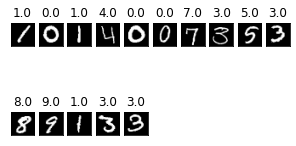

In [6]:
fig=plt.figure(figsize=(5,3))
for i in range(15):
  ax=fig.add_subplot(2,10,i+1,xticks=[],yticks=[])
  ax.imshow(np.squeeze(train_x[i]),cmap='gray')
  ax.set_title(train_y[i])

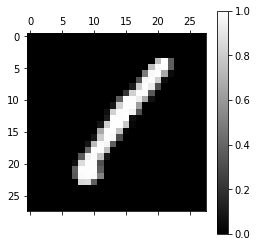

In [7]:
#Verify the normalization work
plt.matshow(train_x[0,:,:,0],cmap='gray')
plt.colorbar()
plt.show()

<h3>One Hot Enconder</h3>

In [8]:
train_y=tf.keras.utils.to_categorical(train_y,10)
train_y.shape

(42000, 10)

In [9]:
#One hot encoder of same label
print(train_y[0:5,:])

[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


<h3>Defining the model</h>

In [10]:
model=tf.keras.models.Sequential([tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
                                  tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
                                  tf.keras.layers.MaxPooling2D(2,2),
                                  tf.keras.layers.Conv2D(64,(3,3),activation='relu',padding='Same'),
                                  tf.keras.layers.Conv2D(64,(3,3),activation='relu',padding='Same'),
                                  tf.keras.layers.MaxPool2D(pool_size=(2,2),strides=(2,2)),
                                  tf.keras.layers.Dropout(0.25),
                                  tf.keras.layers.Conv2D(64,(3,3),activation='relu',padding='Same'),
                                  tf.keras.layers.Conv2D(64,(3,3),activation='relu',padding='Same'),
                                  tf.keras.layers.MaxPool2D(pool_size=(2,2),strides=(2,2)),
                                  tf.keras.layers.Dropout(0.25),
                                  tf.keras.layers.Flatten(),
                                  tf.keras.layers.Dense(256,activation='relu'),
                                  tf.keras.layers.Dense(256,activation='relu'),
                                  tf.keras.layers.Dropout(0.50),
                                  tf.keras.layers.Dense(10,activation='softmax')
                                  ])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 24, 24, 32)        9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 12, 12, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 12, 12, 64)        18496     
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 12, 12, 64)        36928     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 6, 6, 64)          0         
_________________________________________________________________
dropout (Dropout)            (None, 6, 6, 64)          0

2022-08-06 18:01:58.517158: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


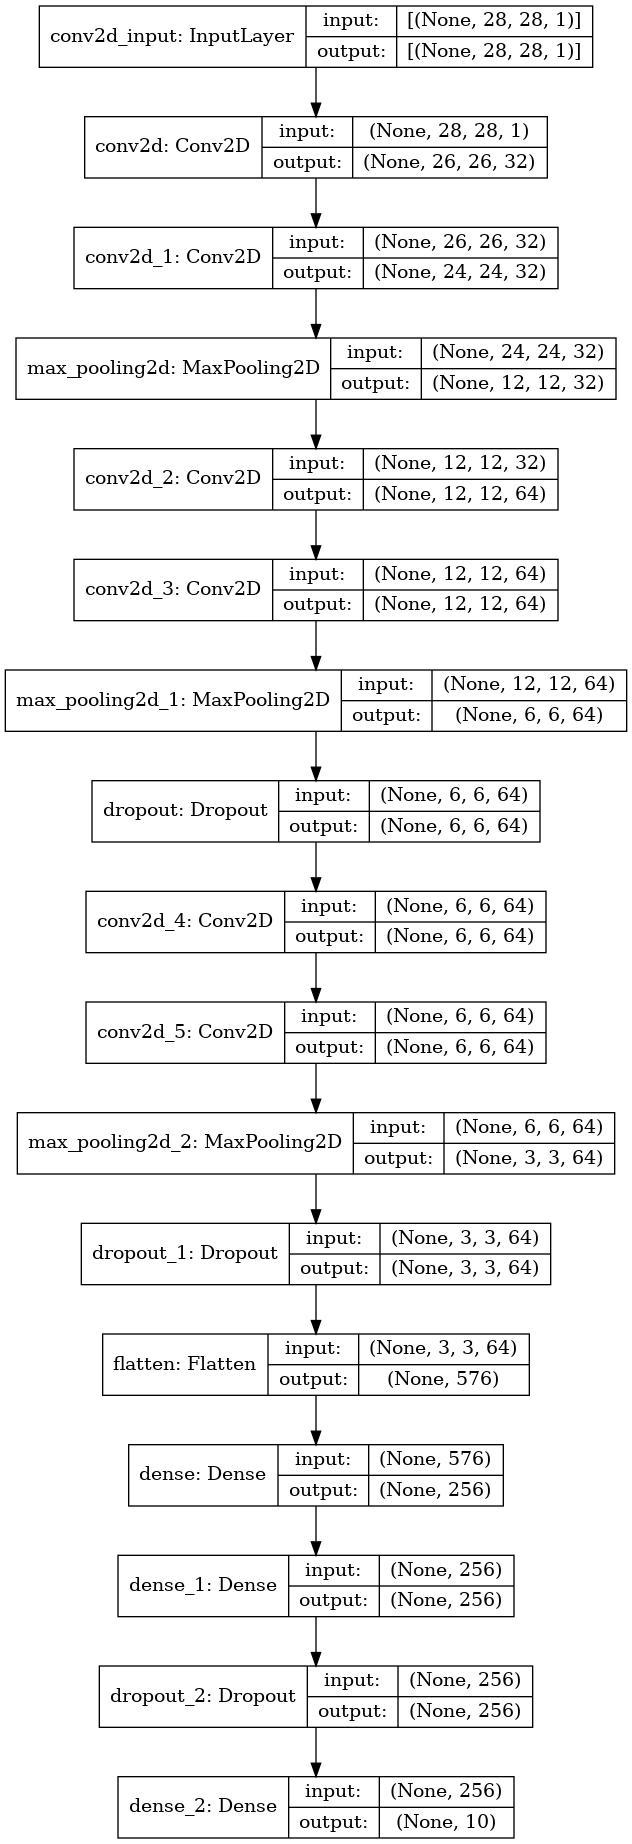

In [11]:
tf.keras.utils.plot_model(model,'model.jpg',show_shapes=True)

In [12]:
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self,epoch,logs={}):
    if(logs.get('accuracy')>0.999):
      print("\nTraining is cancelled because you reached 99.9%")
      self.model.stop_training = True

callbacks=myCallback()

In [13]:
Optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005,
                                   beta_1=0.9,
                                   beta_2=0.999,
                                   epsilon=1e-07,
                                   name='Adam')
model.compile(optimizer=Optimizer,loss='categorical_crossentropy',metrics=['accuracy'])
history=model.fit(train_x,train_y,batch_size=50,epochs=20,callbacks=[callbacks])

2022-08-06 18:02:00.416739: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/20
840/840 [==============================] - 55s 64ms/step - loss: 0.3449 - accuracy: 0.8867
Epoch 2/20
840/840 [==============================] - 55s 65ms/step - loss: 0.0867 - accuracy: 0.9754
Epoch 3/20
840/840 [==============================] - 57s 68ms/step - loss: 0.0619 - accuracy: 0.9818
Epoch 4/20
840/840 [==============================] - 53s 63ms/step - loss: 0.0504 - accuracy: 0.9846
Epoch 5/20
840/840 [==============================] - 55s 66ms/step - loss: 0.0427 - accuracy: 0.9876
Epoch 6/20
840/840 [==============================] - 55s 65ms/step - loss: 0.0350 - accuracy: 0.9897
Epoch 7/20
840/840 [==============================] - 56s 67ms/step - loss: 0.0331 - accuracy: 0.9905
Epoch 8/20
840/840 [==============================] - 57s 68ms/step - loss: 0.0290 - accuracy: 0.9914
Epoch 9/20
840/840 [==============================] - 56s 66ms/step - loss: 0.0268 - accuracy: 0.9918
Epoch 10/20
840/840 [==============================] - 57s 68ms/step - loss: 0.024

<h3>Model Curves</h3>

In [14]:
print(history.params)

{'verbose': 1, 'epochs': 20, 'steps': 840}


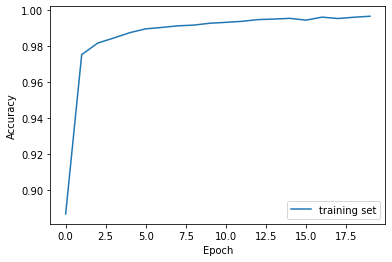

In [15]:

plt.plot(history.history['accuracy'],label='training set')
#plt.plot(history.history['loss'],label='validation set')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training data','validation data'],loc='lower right')
plt.legend()

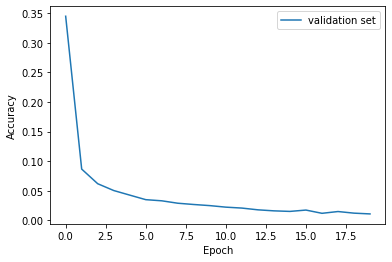

In [16]:

plt.plot(history.history['loss'],label='validation set')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training data','validation data'],loc='lower right')
plt.legend()

In [17]:
results=model.predict(test_x)
results=np.argmax(results,axis=1)
results=pd.Series(results,name='Label')
print(results)

0        2
1        0
2        9
3        9
4        3
        ..
27995    9
27996    7
27997    3
27998    9
27999    2
Name: Label, Length: 28000, dtype: int64


In [18]:
submission=pd.concat([pd.Series(range(1,28001),name='ImageId'),results],axis=1)
submission.to_csv("submission.csv",index=False)